# Training and deployment of a YOLO11 model for Instance Segmentation

## 🌟 Overview

In this tutorial, you will learn how to work with the YOLO11 instance segmentation model from Ultralytics. We’ll guide you through downloading, training, and deploying the model on a Luxonis device, with clear code comments to help you follow along.

## 📜 Table of Contents
- [🛠️ Installation](#️installation)
- [🗃️ Data Preparation](#data-preparation)
- [🏋️‍♂️ Training](#️️training)
- [✍ Validation](#validation)
- [🧠 Infer](#infer)
- [🗂️ Conversion](#conversion)
- [📷 DepthAI Script](#depthai-script)

<a name="️installation"></a>

## 🛠️ Installation

We'll install all the dependencies we'll need.

In [ ]:
%pip install -q ultralytics -U
%pip install -q depthai==3.0.0 -U
%pip install -q depthai-nodes==0.3.0 -U

<a name ="data-preparation"></a>

## 🗃️ Data Preparation


If you use a custom dataset, you must prepare your dataset for training. Once you have set up a YAML file and sorted labels and images into the right directories, you can continue with the next step.

Luckily, we will be using `COCO8 Seg`, for which YAML already exists. You can check it out [here](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/coco8-seg.yaml).

In case you need to train on a custom dataset, please follow these steps:

#### 1. Prepare your own dataset with images
#### 2. Generate label files in YOLO format

One image corresponds to one label text file. Object information per row. Each row contains the following information about the object instance:

- Object class index: An integer representing the class of the object (e.g., 0 for person, 1 for car, etc.).
- Object bounding coordinates: The bounding coordinates around the mask area, normalized to be between 0 and 1.

The label format example is below.
```txt
<class-index> <x1> <y1> <x2> <y2> ... <xn> <yn>
0 0.681 0.483 0.671 0.486 0.671 0.486 0.681 0.490
```

#### 3. Organize directories and create the `.yaml` file.

The config `.yaml` file should have the following structure:
```yaml
# Train/val/test sets as
# 1) dir: path/to/imgs
# 2) file: path/to/imgs.txt, or
# 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: ../dataset/
train: # train images (relative to 'path')
val: # val images (relative to 'path')
test: # test images (optional)

# Classes
names:
  0: [class-0]
  1: [class-1]
  ...

# Download script/URL (optional)
download:
```

For more details about the format, please refer to [this](https://docs.ultralytics.com/datasets/segment/) page.


<a name ="️️training"></a>

## 🏋️‍♂️ Training


Before we begin the training, we have to choose the pre-trained model. This image from `Ultralytics` documentation quickly summarizes them. You can find more about the models [here](https://docs.ultralytics.com/tasks/segment/#models).

<img src="./media/model_zoo.png" alt="YOLO11 Instance Segmentation Model Zoo" width="640">

We select the `YOLO11n` as it is the smallest and quickest. You can also experiment with heavier models, but it might affect the FPS on our devices.

In [2]:
from ultralytics import YOLO

# Load a pretrained model (recommended for training)
model = YOLO("yolo11n-seg.pt")

We will set image size *img* to *640*. We will train the model for *1* *epoch*. We set *data* to `coco8-seg.yaml`.

For the actual training, *epochs* should be higher (typically between *300-1000* epochs).

In [ ]:
# Train the model
results = model.train(data="coco8-seg.yaml", epochs=3, imgsz=640)

<a name ="validation"></a>

## ✍ Validation

After training our model, we can validate it on the validation set of our dataset.

In [ ]:
metrics = model.val()

<a name ="infer"></a>

## 🧠 Infer

Usually, we also want to visualize the prediction of the trained model on some image to ensure it does what it is supposed to do. This is called inference, and we'll perform it on one image.

100%|██████████| 134k/134k [00:00<00:00, 7.04MB/s]

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 116.4ms
Speed: 5.3ms preprocess, 116.4ms inference, 4.8ms postprocess per image at shape (1, 3, 640, 480)


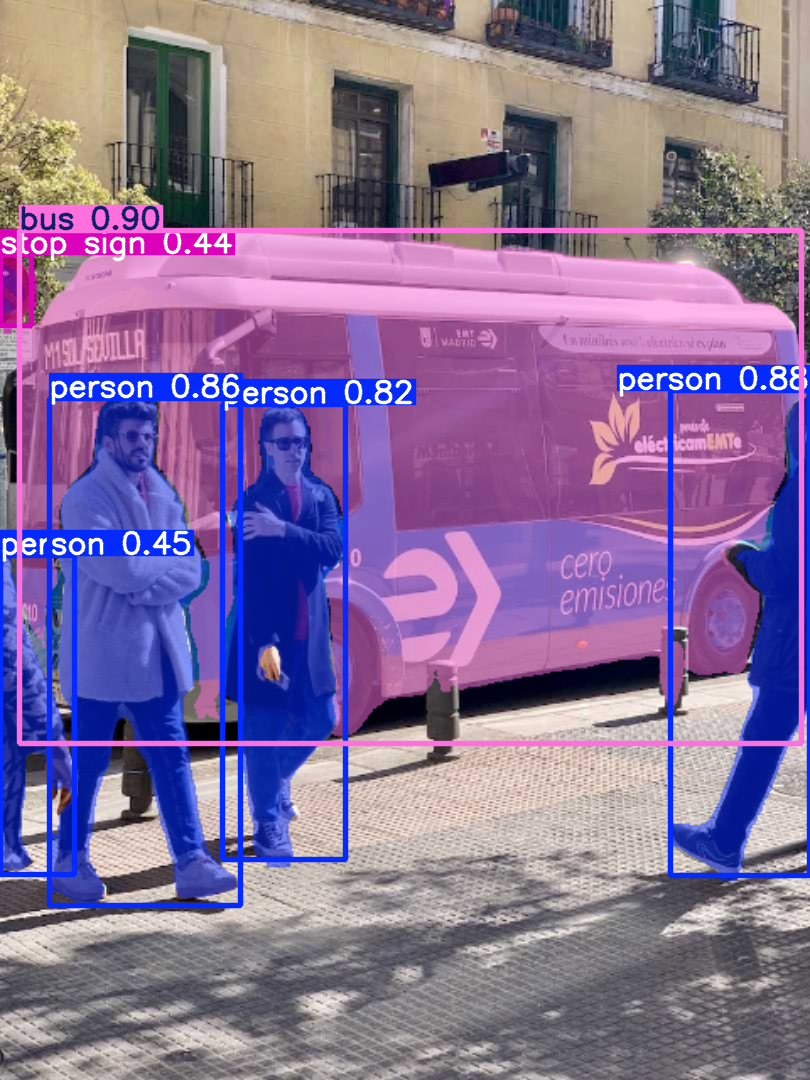

In [6]:
results = model("https://ultralytics.com/images/bus.jpg")  # predict on an image
results[0].show()  # display to screen

<a name="conversion"></a>

## 🗂️ Conversion

By default, the library saves the weights with the best performance into the `best.pt` file inside the corresponding run folder. We'll rename it to reflect the model better.

In [ ]:
import shutil

shutil.copy("runs/segment/train/weights/best.pt", "yolo11n_instance_segmentation_trained.pt")

If you are experiencing the following error:

```
NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968
```

Please run the following command and rerun the previous command:

```python
import locale
locale.getpreferredencoding = lambda: "UTF-8"
```

We have the trained model, and the goal is to deploy it to the Luxonis device. The model's specific format depends on the Luxonis device series you have. We will show you how to use our [`ModelConverter`](https://github.com/luxonis/modelconverter) to convert the model as simply as possible. 

We'll start by installing the `ModelConverter`.

In [ ]:
%pip install -q modelconv==0.4.5 -U

We will use the `ModelConverter` Python API, which leverages our [`HubAI`](https://hub.luxonis.com) platform to perform model conversion in the background. To get started, you'll need to create an account on `HubAI` and obtain your team’s API key.

In [ ]:
HUBAI_API_KEY = "<YOUR_HUBAI_API_KEY>"

Model conversion can be done via either the CLI or the Python API — here, we'll use the latter. For more information, see the [online usage section](https://github.com/luxonis/modelconverter?tab=readme-ov-file#online-usage) of the documentation.

The call below creates a new model card within your team on `HubAI`, uploads the model file and metadata, then performs cloud-side conversion to the selected target platform (e.g., [`RVC2`](https://rvc4.docs.luxonis.com/hardware/platform/rvc/rvc2/), [`RVC4`](https://rvc4.docs.luxonis.com/hardware/platform/rvc/rvc4/)). Once completed, the converted model is automatically downloaded to your device.

For HubAI-specific conversion parameters, refer to the [online conversion section](https://github.com/luxonis/modelconverter/tree/e6a3478ba47d8f92d4d60217f2aee0f4f468cb14/modelconverter/hub#online-conversion) of the ModelConverter documentation. Platform-specific parameters are also documented there.


In [ ]:
from modelconverter import convert

converted_model = convert.RVC2(
    api_key=HUBAI_API_KEY,
    path="yolo11n_instance_segmentation_trained.pt",
    name="YOLO11 Nano COCO8 Instance Segmentation",
    description_short="Trained YOLO11 nano instance segmentation model on COCO8 dataset.",
    yolo_version="yolov11",
    yolo_input_shape="512 288",
    # yolo_class_names=["person"],
    tasks=["INSTANCE_SEGMENTATION"],
    license_type="MIT",
    is_public=False
)

We have successfully converted our trained model for an RVC2 device, so let's test it! Please copy the path to the downloaded archive with the converted model from the output log of the last code cell; we will use it in the next section.

In [ ]:
MODEL_PATH = "<YOUR_DOWNLOADED_MODEL_ARCHIVE_PATH>"

<a name="depthai-script"></a>

## 📷 DepthAI Script

To test our model on one of our cameras, we need to have `DepthAI v3` and `Depthai Nodes` installed. Moreover, the following script must be run locally and requires a Luxonis device connected to your machine.

To run the model on a DepthAI device using the script below, please note the following:

- You can view the output stream by opening [http://localhost:8082](http://localhost:8082) in your browser.

- If you're running the script from a Jupyter Notebook, the output may not appear directly within the notebook. The script should print a link pointing to [http://localhost:8082](http://localhost:8082) for accessing the stream.

- To stop the video stream, press **`q`** while focused on the visualizer page.

In [ ]:
DEVICE = None # Set to None to use the default device, or you can specify a specific device IP

In [ ]:
import depthai as dai
from depthai_nodes.node import ParsingNeuralNetwork, ApplyColormap, ImgFrameOverlay

device = dai.Device(dai.DeviceInfo(DEVICE)) if DEVICE else dai.Device()
platform = device.getPlatform()
img_frame_type = dai.ImgFrame.Type.BGR888i if platform.name == "RVC4" else dai.ImgFrame.Type.BGR888p
visualizer = dai.RemoteConnection(httpPort=8082)

with dai.Pipeline(device) as pipeline:
    cam = pipeline.create(dai.node.Camera).build()
    nn_archive = dai.NNArchive(MODEL_PATH)
    # Create the neural network node
    nn_with_parser = pipeline.create(ParsingNeuralNetwork).build(
        cam.requestOutput((512, 288), type=img_frame_type, fps=30), 
        nn_archive
    )
    # transform output array to colormap
    apply_colormap_node = pipeline.create(ApplyColormap).build(nn_with_parser.out)
    # overlay frames
    overlay_frames_node = pipeline.create(ImgFrameOverlay).build(
        nn_with_parser.passthrough,
        apply_colormap_node.out,
    ) 
    # Configure the visualizer node
    visualizer.addTopic("Video", overlay_frames_node.out, "images")
    visualizer.addTopic("Detections", nn_with_parser.out, "detections")

    pipeline.start()
    visualizer.registerPipeline(pipeline)

    while pipeline.isRunning():
        key = visualizer.waitKey(1)
        if key == ord("q"):
            print("Got q key from the remote connection!")
            break

Yay! 🎉🎉🎉 Huge congratulations, you have successfully finished this tutorial in which you trained and deployed a pre-trained YOLO11 nano instance segmentation model to our cameras!